# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Arkan Hariz Chandrawinata Liem
- **Email:** arkanliem2005@gmail.com
- **ID Dicoding:** arkan_hariz

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana performa dan tren total peminjaman sepeda per bulan sepanjang tahun 2011 hingga 2012, serta pada musim apa permintaan peminjaman sepeda mencapai titik tertinggi?
  - Specific: Fokus pada tren total penyewaan bulanan dan pengaruh musim.
  - Measurable: Dihitung menggunakan agregasi total dan rata-rata metrik peminjaman.
  - Action-oriented: Membantu tim operasional mengatur kapasitas armada sepeda dan alokasi anggaran perawatan menjelang musim puncak.
  - Relevant: Memahami fluktuasi permintaan berbasis waktu dan musim adalah faktor kunci efisiensi bisnis rental sepeda.
  - Time-bound: Terikat pada data Januari 2011 hingga Desember 2012.
- **Pertanyaan 2:** Bagaimana pola peminjaman sepeda pada setiap jam dalam sehari antara hari kerja dibandingkan akhir pekan/libur, serta bagaimana perbedaan karakteristik antara pengguna kasual dan pengguna terdaftar?
  - Specific: Menganalisis distribusi sewa per jam, perbandingan tipe hari, dan segmentasi tipe pengguna.
  - Measurable: Diukur dengan rata-rata peminjaman per jam pada kolom casual, registered, dan cnt.
  - Action-oriented: Mengoptimalkan ketersediaan stok sepeda di jam-jam sibuk (rush hour) dan merancang kampanye konversi pengguna kasual menjadi anggota terdaftar.
  - Relevant: Perbedaan perilaku pengguna komuter dan rekreasi memengaruhi penempatan armada di stasiun-stasiun strategis.
  - Time-bound: Menggunakan seluruh observasi catatan per jam (2011-2012).

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load day_df & hour_df

In [2]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

print(f"Dimensi data harian (day.csv) : {day_df.shape}")
print(f"Dimensi data per jam (hour.csv): {hour_df.shape}")

Dimensi data harian (day.csv) : (731, 16)
Dimensi data per jam (hour.csv): (17379, 17)


**Insight:** (Opsional)
- Dataset harian (day.csv) berisi 731 baris dan 16 kolom, mencakup agregasi peminjaman per hari.
- Dataset per jam (hour.csv) berisi 17.379 baris dan 17 kolom, mencakup agregasi peminjaman per jam.

### Assessing Data

#### Identifying tipe data, missing value, duplikasi, dan nilai kategori yang kurang deskriptif

In [3]:
print("Info Tipe Data day_df")
print(day_df.info())

print("\nMissing Values")
print("day_df  :\n", day_df.isna().sum())
print("hour_df :\n", hour_df.isna().sum())

print(f"\nDuplikasi Baris")
print(f"Duplikat day_df : {day_df.duplicated().sum()}")
print(f"Duplikat hour_df: {hour_df.duplicated().sum()}")

print("\nStatistik Deskriptif (day_df)")
print(day_df.describe())

Info Tipe Data day_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Missing Values
day_df  :
 instant       0
dteday        0
season 

**Steps to Take:**
- Mengonversi kolom `dteday` pada kedua dataset dari tipe object menjadi datetime.
- Memetakan (mapping) kolom kategorikal `season`, `yr`, dan `weathersit` yang masih berupa kode numerik menjadi label yang lebih deskriptif.
- Menghapus kolom `instant` karena hanya berupa indeks dan tidak memiliki nilai analitis.

**Insight:** (Opsional)
- Tidak ditemukan missing value maupun data duplikat pada `day_df` maupun `hour_df`.
- Kolom `dteday` pada kedua dataset masih bertipe data object (Inaccurate Data Type), seharusnya datetime.
- Kolom kategorikal seperti `season`, `yr`, `mnth`, `weathersit`, dan `workingday` berupa kode numerik (1, 2, 3, ...) yang kurang deskriptif untuk dianalisis maupun divisualisasikan.
- Kolom `instant` bersifat redundan karena hanya berupa indeks baris.

### Cleaning Data

#### Fixing tipe data dteday, mapping kategori, dan menghapus kolom redundan

In [9]:
# Cleaning Data

day_clean = day_df.copy()
hour_clean = hour_df.copy()

# Mengubah tipe data dteday menjadi datetime
day_clean['dteday'] = pd.to_datetime(day_clean['dteday'])
hour_clean['dteday'] = pd.to_datetime(hour_clean['dteday'])

# Mapping Nilai Kategori agar lebih deskriptif
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}
yr_mapping = {0: 2011, 1: 2012}

day_clean['season_label'] = day_clean['season'].map(season_mapping)
day_clean['weather_label'] = day_clean['weathersit'].map(weather_mapping)
day_clean['year_actual'] = day_clean['yr'].map(yr_mapping)

hour_clean['season_label'] = hour_clean['season'].map(season_mapping)
hour_clean['weather_label'] = hour_clean['weathersit'].map(weather_mapping)
hour_clean['year_actual'] = hour_clean['yr'].map(yr_mapping)

# Menghapus kolom instant yang tidak digunakan
day_clean.drop(columns=['instant'], inplace=True)
hour_clean.drop(columns=['instant'], inplace=True)

# Validasi Data Setelah Pembersihan
print("Tipe data dteday setelah cleaning:", day_clean['dteday'].dtype)
print("Sampel data day_clean:")
print(day_clean[['dteday', 'year_actual', 'season_label', 'weather_label', 'cnt']].head())

hour_clean.to_csv("main_data.csv", index=False)

print("main_data.csv berhasil disimpan")

Tipe data dteday setelah cleaning: datetime64[ns]
Sampel data day_clean:
      dteday  year_actual season_label        weather_label   cnt
0 2011-01-01         2011       Spring         Misty/Cloudy   985
1 2011-01-02         2011       Spring         Misty/Cloudy   801
2 2011-01-03         2011       Spring  Clear/Partly Cloudy  1349
3 2011-01-04         2011       Spring  Clear/Partly Cloudy  1562
4 2011-01-05         2011       Spring  Clear/Partly Cloudy  1600
main_data.csv berhasil disimpan


**Insight:** (Opsional)
- Kolom `dteday` berhasil dikonversi menjadi tipe datetime pada kedua dataset.
- Kolom baru `season_label`, `weather_label`, dan `year_actual` berhasil ditambahkan untuk mempermudah interpretasi saat EDA dan visualisasi.
- Kolom `instant` yang redundan telah dihapus dari kedua dataset.

## Exploratory Data Analysis (EDA)

### Explore pola peminjaman bulanan, musiman, dan per jam

In [5]:
# EDA

monthly_summary = day_clean.groupby(['year_actual', 'mnth'])['cnt'].sum().reset_index()
monthly_summary['period'] = monthly_summary['year_actual'].astype(str) + '-' + monthly_summary['mnth'].astype(str).str.zfill(2)

# Agregasi rata-rata peminjaman berdasarkan musim
season_summary = day_clean.groupby('season_label').agg({
    'cnt': ['mean', 'max', 'min', 'sum'],
    'casual': 'mean',
    'registered': 'mean'
}).reset_index()

print("Ringkasan Peminjaman per Musim:")
print(season_summary)

hourly_daytype = hour_clean.groupby(['hr', 'workingday']).agg({
    'casual': 'mean',
    'registered': 'mean',
    'cnt': 'mean'
}).reset_index()

# Menambahkan label hari kerja
hourly_daytype['day_type'] = hourly_daytype['workingday'].map({1: 'Hari Kerja (Workingday)', 0: 'Hari Libur / Akhir Pekan'})

print("\nSampel Rata-rata Peminjaman per Jam:")
print(hourly_daytype.head(6))

Ringkasan Peminjaman per Musim:
  season_label          cnt                            casual   registered
                       mean   max   min      sum         mean         mean
0         Fall  5644.303191  8714  1115  1061129  1202.611702  4441.691489
1       Spring  2604.132597  7836   431   471348   334.928177  2269.204420
2       Summer  4992.331522  8362   795   918589  1106.097826  3886.233696
3       Winter  4728.162921  8555    22   841613   729.112360  3999.050562

Sampel Rata-rata Peminjaman per Jam:
   hr  workingday     casual  registered        cnt                  day_type
0   0           0  16.647826   74.152174  90.800000  Hari Libur / Akhir Pekan
1   0           1   7.149194   29.637097  36.786290   Hari Kerja (Workingday)
2   1           0  12.504348   57.004348  69.508696  Hari Libur / Akhir Pekan
3   1           1   3.710526   12.842105  16.552632   Hari Kerja (Workingday)
4   2           0  10.399123   42.771930  53.171053  Hari Libur / Akhir Pekan
5   2       

**Insight:** (Opsional)
- Rata-rata peminjaman harian tertinggi terjadi pada musim Fall, diikuti Summer, sedangkan Spring mencatat rata-rata terendah.
- Terdapat perbedaan pola rata-rata peminjaman per jam antara hari kerja dan hari libur/akhir pekan, baik dari sisi total peminjaman (`cnt`) maupun proporsi pengguna `casual` dan `registered`.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa dan tren total peminjaman sepeda per bulan sepanjang tahun 2011 hingga 2012, serta pada musim apa permintaan peminjaman sepeda mencapai titik tertinggi ?

/tmp/ipykernel_508/2397101560.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_508/2397101560.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


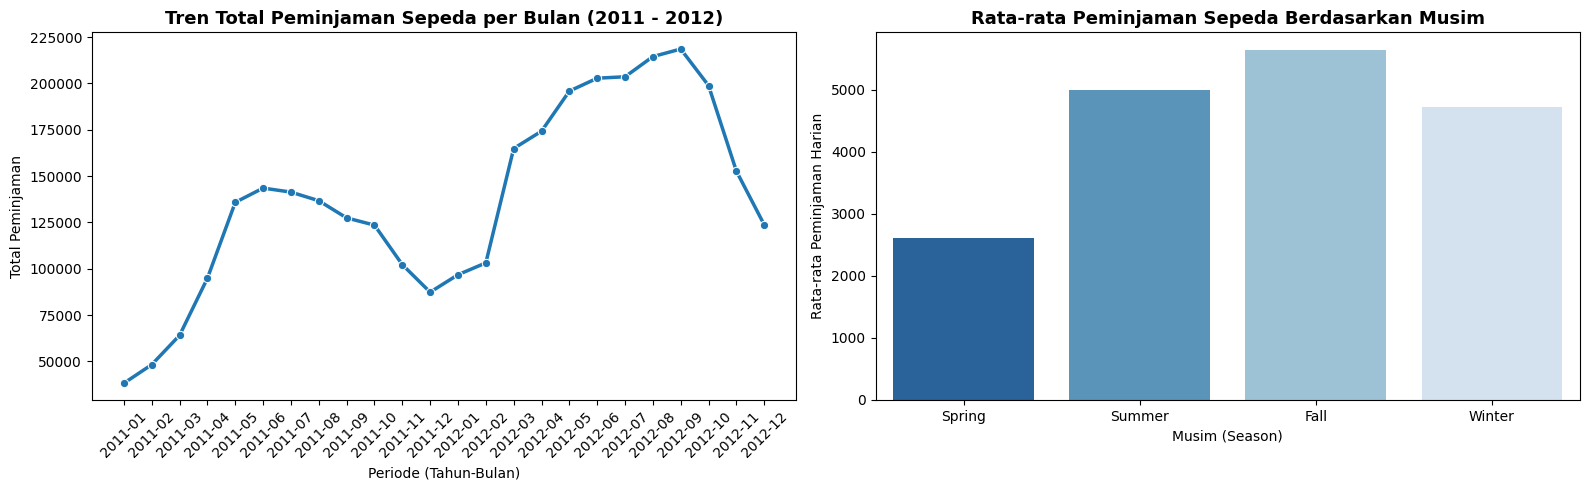

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1A: Tren Bulanan 2011-2012
sns.lineplot(
    data=monthly_summary,
    x='period',
    y='cnt',
    marker='o',
    linewidth=2.5,
    color='#1f77b4',
    ax=axes[0]
)
axes[0].set_title('Tren Total Peminjaman Sepeda per Bulan (2011 - 2012)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Periode (Tahun-Bulan)')
axes[0].set_ylabel('Total Peminjaman')
axes[0].tick_params(axis='x', rotation=45)

# Plot 1B: Rata-rata Peminjaman Berdasarkan Musim
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
sns.barplot(
    data=day_clean,
    x='season_label',
    y='cnt',
    order=season_order,
    palette='Blues_r',
    ci=None,
    ax=axes[1]
)
axes[1].set_title('Rata-rata Peminjaman Sepeda Berdasarkan Musim', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Musim (Season)')
axes[1].set_ylabel('Rata-rata Peminjaman Harian')

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana pola peminjaman sepeda pada setiap jam dalam sehari antara hari kerja dibandingkan akhir pekan/libur, serta bagaimana perbedaan karakteristik antara pengguna kasual dan pengguna terdaftar ?

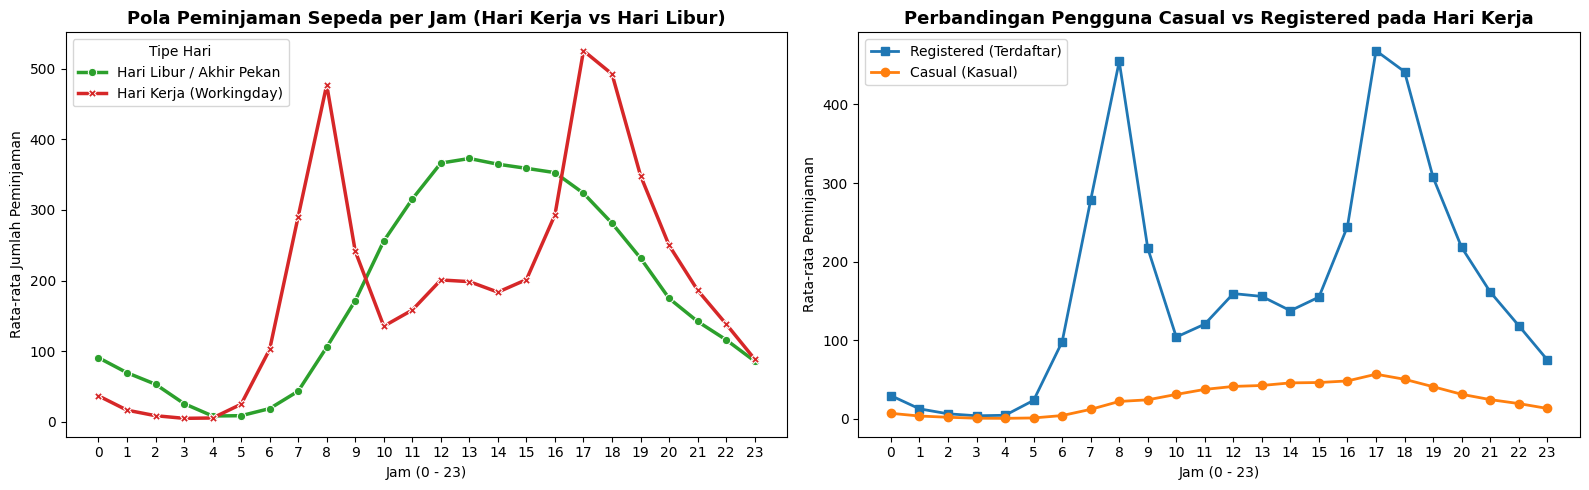

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 2A: Pola Jam Hari Kerja vs Hari Libur
sns.lineplot(
    data=hourly_daytype,
    x='hr',
    y='cnt',
    hue='day_type',
    style='day_type',
    markers=True,
    dashes=False,
    palette=['#2ca02c', '#d62728'],
    linewidth=2.5,
    ax=axes[0]
)
axes[0].set_title('Pola Peminjaman Sepeda per Jam (Hari Kerja vs Hari Libur)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jam (0 - 23)')
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman')
axes[0].set_xticks(range(0, 24))
axes[0].legend(title='Tipe Hari')

# Plot 2B: Casual vs Registered pada Hari Kerja
hourly_work = hourly_daytype[hourly_daytype['workingday'] == 1]
axes[1].plot(hourly_work['hr'], hourly_work['registered'], marker='s', label='Registered (Terdaftar)', color='#1f77b4', linewidth=2)
axes[1].plot(hourly_work['hr'], hourly_work['casual'], marker='o', label='Casual (Kasual)', color='#ff7f0e', linewidth=2)
axes[1].set_title('Perbandingan Pengguna Casual vs Registered pada Hari Kerja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jam (0 - 23)')
axes[1].set_ylabel('Rata-rata Peminjaman')
axes[1].set_xticks(range(0, 24))
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Total peminjaman sepeda meningkat signifikan dari tahun 2011 ke 2012 di hampir semua bulan, dengan musim Fall mencatat rata-rata peminjaman harian tertinggi ($\approx 5.644$ sewa/hari) dan musim Spring terendah ($\approx 2.604$ sewa/hari).
- Pada hari kerja, pola peminjaman berbentuk bimodal dengan dua puncak tajam di jam 08:00 dan 17:00-18:00, didominasi pengguna `registered` (mengindikasikan penggunaan sebagai transportasi komuter).
- Pada hari libur/akhir pekan, peminjaman meningkat bertahap dan memuncak pada pukul 12:00-16:00, dengan kontribusi pengguna `casual` yang meningkat signifikan untuk aktivitas rekreasi.

## Analisis Lanjutan (Opsional)

Korelasi Faktor Cuaca terhadap Peminjaman:
cnt           1.000000
registered    0.945517
casual        0.672804
atemp         0.631066
temp          0.627494
hum          -0.100659
windspeed    -0.234545
Name: cnt, dtype: float64


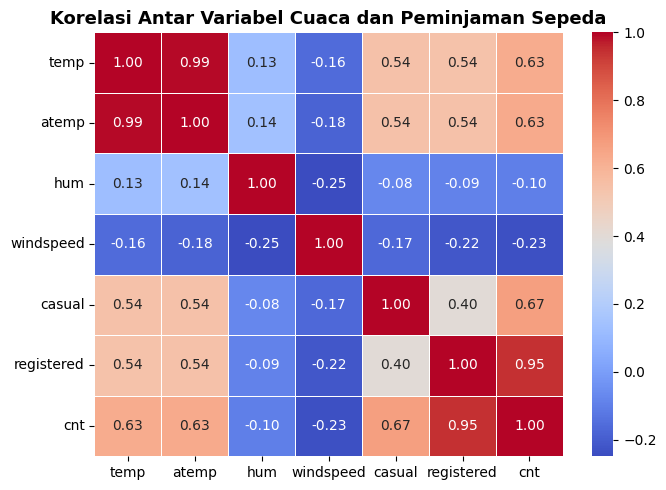

Rata-rata Peminjaman Berdasarkan Kategori Suhu:
  temp_category          cnt       casual   registered
0        Dingin  1703.174603   132.619048  1570.555556
1         Sejuk  3758.453947   584.342105  3174.111842
2        Hangat  5647.102894  1210.733119  4436.369775
3         Panas  5406.792453  1084.603774  4322.188679


/tmp/ipykernel_508/3276747608.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_group_summary, x='temp_category', y='cnt', order=labels, palette='YlOrRd')


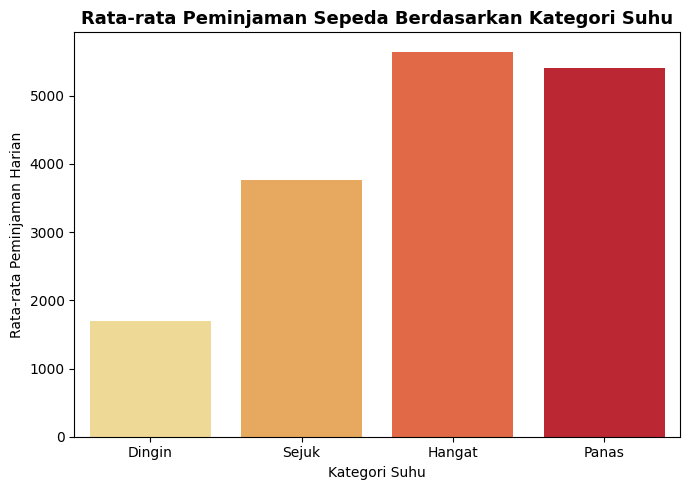

In [8]:
weather_corr = day_clean[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].corr()

print("Korelasi Faktor Cuaca terhadap Peminjaman:")
print(weather_corr['cnt'].sort_values(ascending=False))

plt.figure(figsize=(7, 5))
sns.heatmap(weather_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Korelasi Antar Variabel Cuaca dan Peminjaman Sepeda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Membuat kategori suhu (binning) dari kolom temp (skala 0-1, sudah dinormalisasi)
bins = [0, 0.25, 0.5, 0.75, 1.0]
labels = ['Dingin', 'Sejuk', 'Hangat', 'Panas']
day_clean['temp_category'] = pd.cut(day_clean['temp'], bins=bins, labels=labels, include_lowest=True)

temp_group_summary = day_clean.groupby('temp_category', observed=True).agg({
    'cnt': 'mean',
    'casual': 'mean',
    'registered': 'mean'
}).reset_index()

print("Rata-rata Peminjaman Berdasarkan Kategori Suhu:")
print(temp_group_summary)

plt.figure(figsize=(7, 5))
sns.barplot(data=temp_group_summary, x='temp_category', y='cnt', order=labels, palette='YlOrRd')
plt.title('Rata-rata Peminjaman Sepeda Berdasarkan Kategori Suhu', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Suhu')
plt.ylabel('Rata-rata Peminjaman Harian')
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Suhu (`temp`/`atemp`) memiliki korelasi positif paling kuat terhadap jumlah peminjaman (`cnt`), menunjukkan bahwa cuaca yang lebih hangat mendorong lebih banyak peminjaman sepeda, terutama pada pengguna `casual`.
- Kelembapan (`hum`) dan kecepatan angin (`windspeed`) menunjukkan korelasi negatif terhadap `cnt`, artinya kondisi lembap dan berangin cenderung menurunkan minat peminjaman.
- Hasil manual grouping berdasarkan kategori suhu menunjukkan rata-rata peminjaman meningkat dari kategori 'Dingin' menuju 'Hangat', namun sedikit menurun pada kategori 'Panas', mengindikasikan suhu yang terlalu ekstrem (baik dingin maupun panas) kurang ideal bagi aktivitas bersepeda.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Total peminjaman sepeda mengalami kenaikan volume signifikan dari tahun 2011 ke tahun 2012 di hampir semua bulan. Musim Gugur (Fall) mencatat rata-rata peminjaman harian tertinggi (mencapai rata-rata $\approx 5.644$ sewa/hari), diikuti oleh Musim Panas (Summer), sedangkan Musim Semi (Spring) mencatat tingkat permintaan terendah ($\approx 2.604$ sewa/hari) akibat suhu dingin awal tahun.
- **Conclusion pertanyaan 2:** Pada Hari Kerja (Workingday), grafik membentuk pola bimodal (dua puncak) yang tajam pada jam 08:00 pagi dan 17:00-18:00 sore, didominasi penuh oleh pengguna terdaftar (registered), menandakan penggunaan sepeda sebagai moda transportasi komuter harian. Pada Hari Libur/Akhir Pekan, peminjaman meningkat bertahap mulai siang hingga sore hari (puncaknya pukul 12:00-16:00), di mana kontribusi pengguna kasual (casual) meningkat signifikan untuk aktivitas rekreasi santai.

**Rekomendasi Action Item:**
- Optimalisasi Logistik Armada Berbasis Jam Kerja: Alokasikan unit sepeda ekstra dan percepat relokasi sepeda antarstasiun komuter utama sebelum pukul 07:30 dan 16:30 pada hari kerja untuk mencegah kehabisan stok di stasiun transit/perkantoran.
- Strategi Konversi Pengguna Kasual ke Registered: Terapkan program loyalitas dan diskon berlangganan khusus bagi pengguna kasual yang aktif menyewa pada akhir pekan di musim panas dan gugur agar terdorong mendaftar menjadi pengguna harian.
- Penyesuaian Kapasitas Musiman: Jadwalkan perawatan besar-besaran (maintenance) armada sepeda pada musim semi (Spring) saat permintaan berada pada titik terendah.